In [2]:
#library for loading data from huggingface
!pip install datasets

     -------------------------------------- 515.2/515.2 KB 4.6 MB/s eta 0:00:00
     ---------------------------------------- 26.2/26.2 MB 7.2 MB/s eta 0:00:00
     -------------------------------------- 119.7/119.7 KB 7.3 MB/s eta 0:00:00
     -------------------------------------- 133.5/133.5 KB 7.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.1
    Uninstalling pyarrow-19.0.1:
      Successfully uninstalled pyarrow-19.0.1


You should consider upgrading via the 'C:\Users\veera\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip' command.


In [4]:
#install all libraries
!pip -q install pandas matplotlib seaborn great_expectations

You should consider upgrading via the 'C:\Users\veera\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip' command.


In [25]:
#load data
from datasets import load_dataset
dataset = load_dataset("argilla/uber-reviews")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'inputs', 'prediction', 'prediction_agent', 'annotation', 'annotation_agent', 'multi_label', 'explanation', 'id', 'metadata', 'status', 'event_timestamp', 'metrics'],
        num_rows: 2347
    })
})

In [27]:
#convert to df
df = dataset.to_pandas()
df.head()

,text,inputs,prediction,prediction_agent,annotation,annotation_agent,multi_label,explanation,id,metadata,status,event_timestamp,metrics
0,Uber has done a great job to provide us an alt...,{'text': 'Uber has done a great job to provide...,"[{'label': '5', 'score': 1.0}]",Argilla,None,None,False,None,00029140-3e1a-41ca-be26-a30fdd36d29e,None,Default,2017-09-29,{'text_length': 168}
1,I've drove Uber for several months last year. ...,{'text': 'I've drove Uber for several months l...,"[{'label': '1', 'score': 1.0}]",Argilla,None,None,False,None,001d6833-4121-4059-b521-6b1bf997b8f2,None,Default,2017-10-09,{'text_length': 510}
2,I have a worst experience in UBER. Most Cheate...,{'text': 'I have a worst experience in UBER. M...,"[{'label': '1', 'score': 1.0}]",Argilla,None,None,False,None,00301095-71a4-4543-a026-56e0a699aad9,None,Default,2016-04-28,{'text_length': 169}
3,I just received an odd snail mail supposedly f...,{'text': 'I just received an odd snail mail su...,"[{'label': '1', 'score': 1.0}]",Argilla,None,None,False,None,00398cff-48f3-43e2-a164-e0ac63a4797d,None,Default,2017-12-11,{'text_length': 409}
4,I made an Uber reservation and after waiting f...,{'text': 'I made an Uber reservation and after...,"[{'label': '1', 'score': 1.0}]",Argilla,None,None,False,None,003eb096-04ea-421e-9235-674ad6bc3681,None,Default,2017-04-28,{'text_length': 414}


In [30]:
#shape and columns
df.shape, df.columns

((2347, 13),
 Index(['text', 'inputs', 'prediction', 'prediction_agent', 'annotation',
        'annotation_agent', 'multi_label', 'explanation', 'id', 'metadata',
        'status', 'event_timestamp', 'metrics'],
       dtype='object'))

In [31]:
#data types
df.dtypes

text                        object
inputs                      object
prediction                  object
prediction_agent            object
annotation                  object
annotation_agent            object
multi_label                   bool
explanation                 object
id                          object
metadata                    object
status                      object
event_timestamp     datetime64[us]
metrics                     object
dtype: object

In [33]:
#missing values
df.isna().sum()

text                   0
inputs                 0
prediction             0
prediction_agent       0
annotation          2347
annotation_agent    2347
multi_label            0
explanation         2347
id                     0
metadata            2347
status                 0
event_timestamp        0
metrics                0
dtype: int64

In [34]:
#inspect core columns
df[["text", "prediction", "status", "multi_label"]].head()

,text,prediction,status,multi_label
0,Uber has done a great job to provide us an alt...,"[{'label': '5', 'score': 1.0}]",Default,False
1,I've drove Uber for several months last year. ...,"[{'label': '1', 'score': 1.0}]",Default,False
2,I have a worst experience in UBER. Most Cheate...,"[{'label': '1', 'score': 1.0}]",Default,False
3,I just received an odd snail mail supposedly f...,"[{'label': '1', 'score': 1.0}]",Default,False
4,I made an Uber reservation and after waiting f...,"[{'label': '1', 'score': 1.0}]",Default,False


In [35]:
#Text Length Statistics
df["text_length"] = df["text"].str.len()
df["text_length"].describe()

count    2347.000000
mean      536.579463
std       425.540598
min        11.000000
25%       283.000000
50%       470.000000
75%       682.500000
max      9181.000000
Name: text_length, dtype: float64

In [36]:
#predition label distribution
df["prediction"].value_counts()

prediction
[{'label': '1', 'score': 1.0}]    1777
[{'label': '5', 'score': 1.0}]     235
[{'label': '4', 'score': 1.0}]     118
[{'label': '2', 'score': 1.0}]     117
[{'label': '3', 'score': 1.0}]     100
Name: count, dtype: int64

In [37]:
df["status"].value_counts()

status
Default    2347
Name: count, dtype: int64

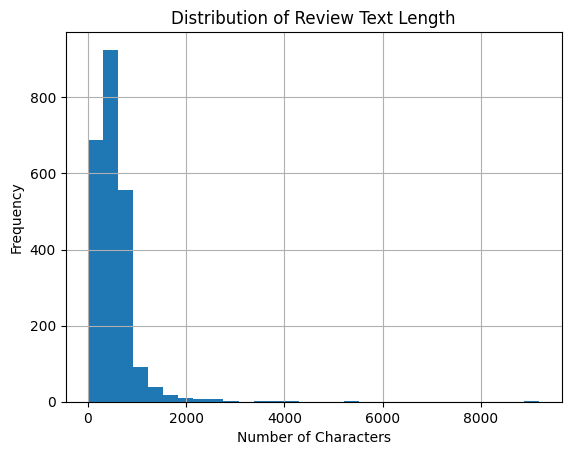

In [38]:
#Text Length Distribution - visualization
import matplotlib.pyplot as plt

plt.figure()
df["text_length"].hist(bins=30)
plt.title("Distribution of Review Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

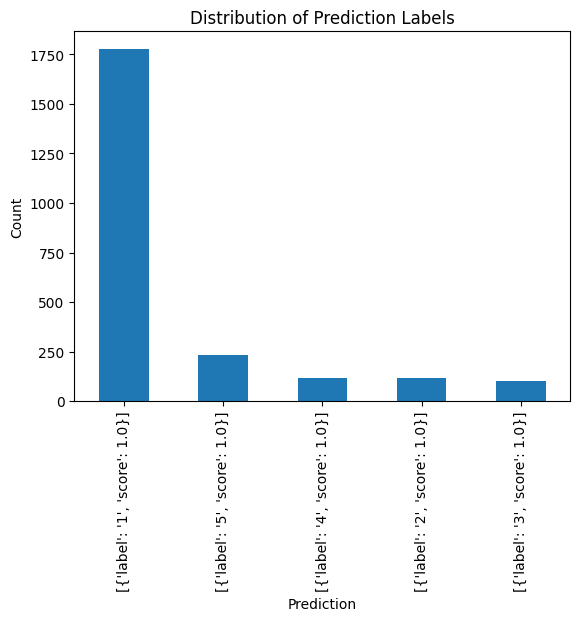

In [40]:
#Prediction label distribution
df["prediction"].value_counts().plot(kind="bar")
plt.title("Distribution of Prediction Labels")
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.show()

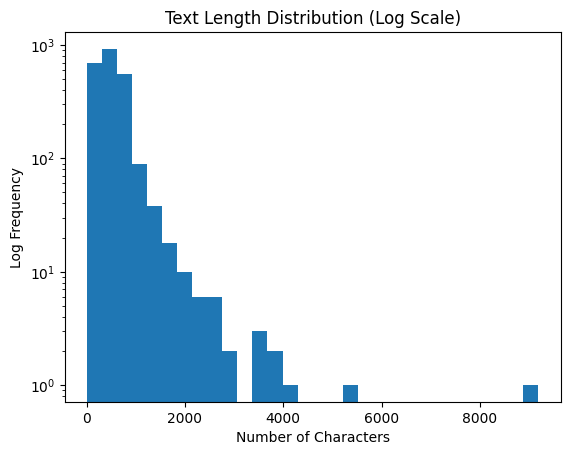

In [41]:
#Text length distribution (log scale)
plt.figure()
plt.hist(df["text_length"], bins=30, log=True)
plt.title("Text Length Distribution (Log Scale)")
plt.xlabel("Number of Characters")
plt.ylabel("Log Frequency")
plt.show()

In [56]:
import great_expectations.expectations as gxe

In [57]:
expectations = [
    gxe.ExpectColumnValuesToNotBeNull(column="text"),
    gxe.ExpectColumnValuesToNotBeNull(column="prediction"),
    gxe.ExpectColumnValuesToBeInSet(column="multi_label", value_set=[True, False]),
    gxe.ExpectColumnValuesToBeNull(column="annotation"),
]

In [58]:
import pandas as pd

def run_expectations(df: pd.DataFrame, expectations):
    results = []
    for exp in expectations:
        col = exp.column

        if exp.__class__.__name__ == "ExpectColumnValuesToNotBeNull":
            success = df[col].notna().all()
            details = {"null_count": int(df[col].isna().sum())}

        elif exp.__class__.__name__ == "ExpectColumnValuesToBeNull":
            success = df[col].isna().all()
            details = {"non_null_count": int(df[col].notna().sum())}

        elif exp.__class__.__name__ == "ExpectColumnValuesToBeInSet":
            allowed = set(exp.value_set)
            success = df[col].isin(allowed).all()
            details = {"invalid_count": int((~df[col].isin(allowed)).sum())}

        results.append({
            "expectation": exp.__class__.__name__,
            "column": col,
            "success": success,
            **details
        })

    return pd.DataFrame(results)

gx_results = run_expectations(df, expectations)
gx_results

,expectation,column,success,null_count,invalid_count,non_null_count
0,ExpectColumnValuesToNotBeNull,text,True,0.0,NaN,NaN
1,ExpectColumnValuesToNotBeNull,prediction,True,0.0,NaN,NaN
2,ExpectColumnValuesToBeInSet,multi_label,True,NaN,0.0,NaN
3,ExpectColumnValuesToBeNull,annotation,True,NaN,NaN,0.0


In [ ]:
"""
Insights: 
1. The dataset contains 2,347 Uber user reviews and is structurally consistent with no missing values in core fields such 
as text, prediction, status, and event_timestamp.

2. Several columns (annotation, annotation_agent, explanation, and metadata) are 100% missing, indicating they are unused or optional in this 
dataset version.

3. Review text length shows a strong right-skewed distribution. 
Most reviews are relatively short (median ≈ 470 characters), while a small number of reviews are extremely long 
(up to ~9,000 characters). 

4. The prediction label distribution is highly imbalanced, with label 1 accounting for the majority of predictions. 
This suggests that most reviews are classified into a single dominant sentiment category.

5. Great Expectations validation confirmed high data quality for key fields:
    No missing values in text or prediction
    multi_label contains only valid boolean values
    annotation is consistently null, matching expectations from EDA

Overall, the dataset is clean, consistent, and good for analysis or modeling. 
"""